

1.   CT204/109438/22 Felix Okoth
2.   CT204/109403/22 Ryan Gitonga
3.   CT2O4/109431/22 Noella Imali



## Import Libraries

In [ ]:
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

Importing Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shahidulugvcse/national-flowers")
print("Dataset path:", path)

100%|██████████| 200M/200M [00:05<00:00, 37.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/shahidulugvcse/national-flowers/versions/1


## Sampling Dataset


In [ ]:
import shutil
import os

# Define the new base directory for the sampled dataset
sampled_base_dir = 'flowers'

# Define the paths for the sampled train and test directories
sampled_dataset_path = os.path.join(sampled_base_dir, 'flowerdataset')

# Remove the sampled dataset directory if it already exists
if os.path.exists(sampled_dataset_path):
    shutil.rmtree(sampled_dataset_path)
    print(f"Removed existing sampled dataset directory: {sampled_dataset_path}")
else:
    print(f"Sampled dataset directory not found at {sampled_dataset_path}. No removal needed.")

Removed existing sampled dataset directory: flowers/flowerdataset


In [ ]:
import os
import shutil
import random

# Define the number of images to sample per class
NUM_IMAGES_PER_CLASS_TRAIN = 80
NUM_IMAGES_PER_CLASS_TEST = 20

# Define the original dataset path
original_path = path

# Define the new base directory for the sampled dataset
sampled_base_dir = output_dir

# Define the paths for the sampled train and test directories
sampled_train_dir = os.path.join(sampled_base_dir, 'flowerdataset', 'train')
sampled_test_dir = os.path.join(sampled_base_dir, 'flowerdataset', 'test')

# Create the base directory if it doesn't exist
os.makedirs(sampled_base_dir, exist_ok=True)

# Class name for original dataset
class_names = os.listdir(os.path.join(original_path, 'flowerdataset', 'train'))
class_names.sort()

print(f"Sampling for classes: {class_names}")

for class_name in class_names:
    original_class_train_path = os.path.join(original_path, 'flowerdataset', 'train', class_name)
    original_class_test_path = os.path.join(original_path, 'flowerdataset', 'test', class_name)

    # Create destination directories
    os.makedirs(os.path.join(sampled_train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(sampled_test_dir, class_name), exist_ok=True)

    # Sample for training set
    all_train_images = [f for f in os.listdir(original_class_train_path) if os.path.isfile(os.path.join(original_class_train_path, f))]
    random.shuffle(all_train_images)
    selected_train_images = all_train_images[:NUM_IMAGES_PER_CLASS_TRAIN]

    for img_name in selected_train_images:
        src = os.path.join(original_class_train_path, img_name)
        dst = os.path.join(sampled_train_dir, class_name, img_name)
        shutil.copyfile(src, dst)

    # Sample for test set
    all_test_images = [f for f in os.listdir(original_class_test_path) if os.path.isfile(os.path.join(original_class_test_path, f))]
    random.shuffle(all_test_images)
    selected_test_images = all_test_images[:NUM_IMAGES_PER_CLASS_TEST]

    for img_name in selected_test_images:
        src = os.path.join(original_class_test_path, img_name)
        dst = os.path.join(sampled_test_dir, class_name, img_name)
        shutil.copyfile(src, dst)

print("Dataset sampling complete.")

Sampling for classes: ['Daisy', 'Dandelion', 'Lavender', 'Lilly', 'Lotus', 'Orchid', 'Rose', 'Sunflower', 'Tulip']
Dataset sampling complete.


## Update Data Path


In [ ]:
path = "flowers"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
print("Defined path, IMG_SIZE, BATCH_SIZE, and SEED.")

Defined path, IMG_SIZE, BATCH_SIZE, and SEED.


In [ ]:
train_ds = image_dataset_from_directory(
    directory=os.path.join(path, 'flowerdataset', 'train'),
    labels="inferred",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    directory=os.path.join(path, 'flowerdataset', 'test'),
    labels="inferred",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Loaded training and validation datasets.")

Found 720 files belonging to 9 classes.
Found 180 files belonging to 9 classes.
Classes: ['Daisy', 'Dandelion', 'Lavender', 'Lilly', 'Lotus', 'Orchid', 'Rose', 'Sunflower', 'Tulip']
Loaded training and validation datasets.


## Optimize Dataset


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
print("Datasets optimized with caching, shuffling, and prefetching.")

Datasets optimized with caching, shuffling, and prefetching.


## Define CNN Model

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(256,3,activation='relu'), layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names),activation='softmax')
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,169 (37.49 MB)

 Trainable params: 9,828,169 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

EPOCHS = 25
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.5370 - loss: 1.3243 - val_accuracy: 0.3722 - val_loss: 1.9392 - learning_rate: 2.0000e-04
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.5516 - loss: 1.2934 - val_accuracy: 0.3778 - val_loss: 1.9379 - learning_rate: 2.0000e-04
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 105s 5s/step - accuracy: 0.5808 - loss: 1.2095 - val_accuracy: 0.3778 - val_loss: 2.0593 - learning_rate: 2.0000e-04
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.5670 - loss: 1.2120 - val_accuracy: 0.4000 - val_loss: 2.1036 - learning_rate: 2.0000e-04
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.6028 - loss: 1.1513 - val_accuracy: 0.4000 - val_loss: 2.0522 - learning_rate: 2.0000e-04
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.6357 - loss: 1.0528 - val_accuracy: 0.4222 - val_loss: 2.0223 - learning_rate: 4.0000e-05
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 109s 5s/step - accuracy: 0.5812 

## Evaluate Model Performance

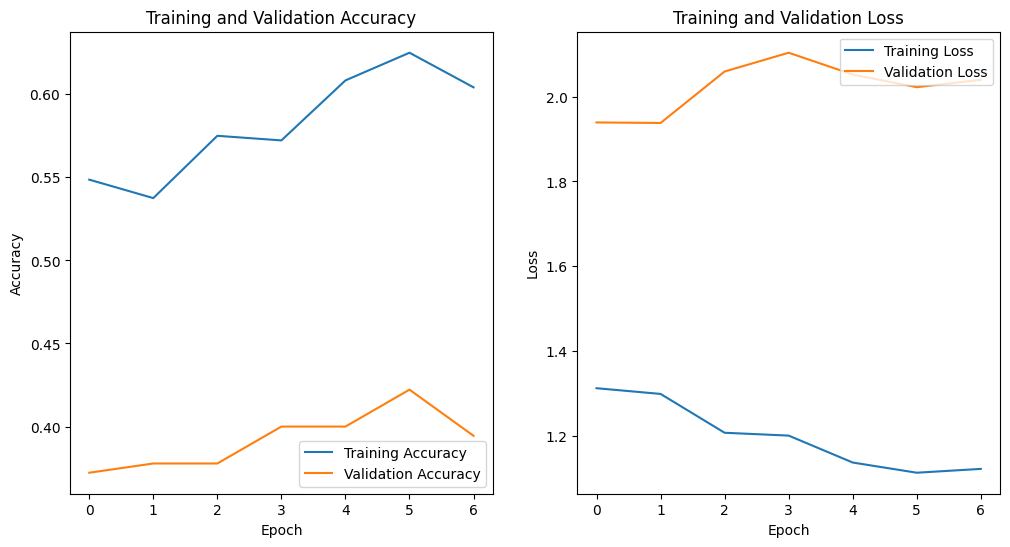

Plots for training and validation accuracy and loss over epochs displayed.


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

print("Plots for training and validation accuracy and loss over epochs displayed.")

## Fine-tune Model


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Create the base model from the pre-trained MobileNetV2 model
IMG_SHAPE = IMG_SIZE + (3,)
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create the new model on top of the pre-trained base
new_model = models.Sequential([
    layers.Input(shape=IMG_SHAPE),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

# Compile the model
new_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Display the model summary
new_model.summary()
print("New model with MobileNetV2 base built, compiled, and summarized.")

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

New model with MobileNetV2 base built, compiled, and summarized.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

EPOCHS_TRANSFER_LEARNING = 20 #epochs for transfer learning
history_transfer_learning = new_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER_LEARNING,
    callbacks=[early_stopping, reduce_lr]
)
print("New MobileNetV2 model training complete.")

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.2641 - loss: 2.3745 - val_accuracy: 0.5111 - val_loss: 1.4497 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6457 - loss: 1.0650 - val_accuracy: 0.6222 - val_loss: 1.4482 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7069 - loss: 0.9078 - val_accuracy: 0.6444 - val_loss: 1.4431 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8095 - loss: 0.6294 - val_accuracy: 0.6389 - val_loss: 1.4973 - learning_rate: 0.0010
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7866 - loss: 0.6176 - val_accuracy: 0.6278 - val_loss: 1.5109 - learning_rate: 0.0010
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8182 - loss: 0.5686 - val_accuracy: 0.6611 - val_loss: 1.5269 - learning_rate: 0.0010
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8494 - loss: 0.4743 - val_accuracy: 

 Model Evaluation



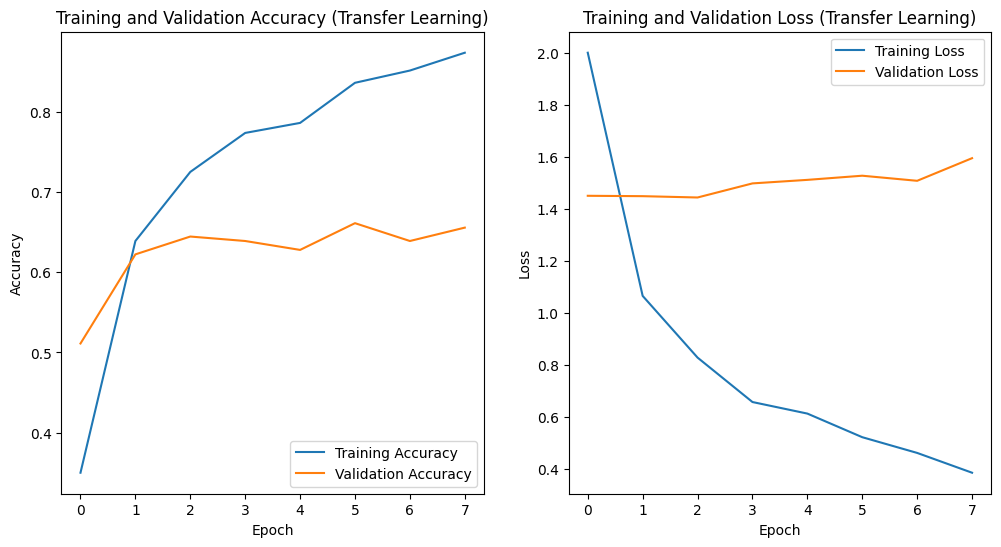

Plots for transfer learning model's training and validation accuracy and loss over epochs displayed.


In [ ]:
acc_transfer = history_transfer_learning.history['accuracy']
val_acc_transfer = history_transfer_learning.history['val_accuracy']

loss_transfer = history_transfer_learning.history['loss']
val_loss_transfer = history_transfer_learning.history['val_loss']

epochs_range_transfer = range(len(acc_transfer))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_transfer, acc_transfer, label='Training Accuracy')
plt.plot(epochs_range_transfer, val_acc_transfer, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_transfer, loss_transfer, label='Training Loss')
plt.plot(epochs_range_transfer, val_loss_transfer, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

print("Plots for transfer learning model's training and validation accuracy and loss over epochs displayed.")

## Visualize Model Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


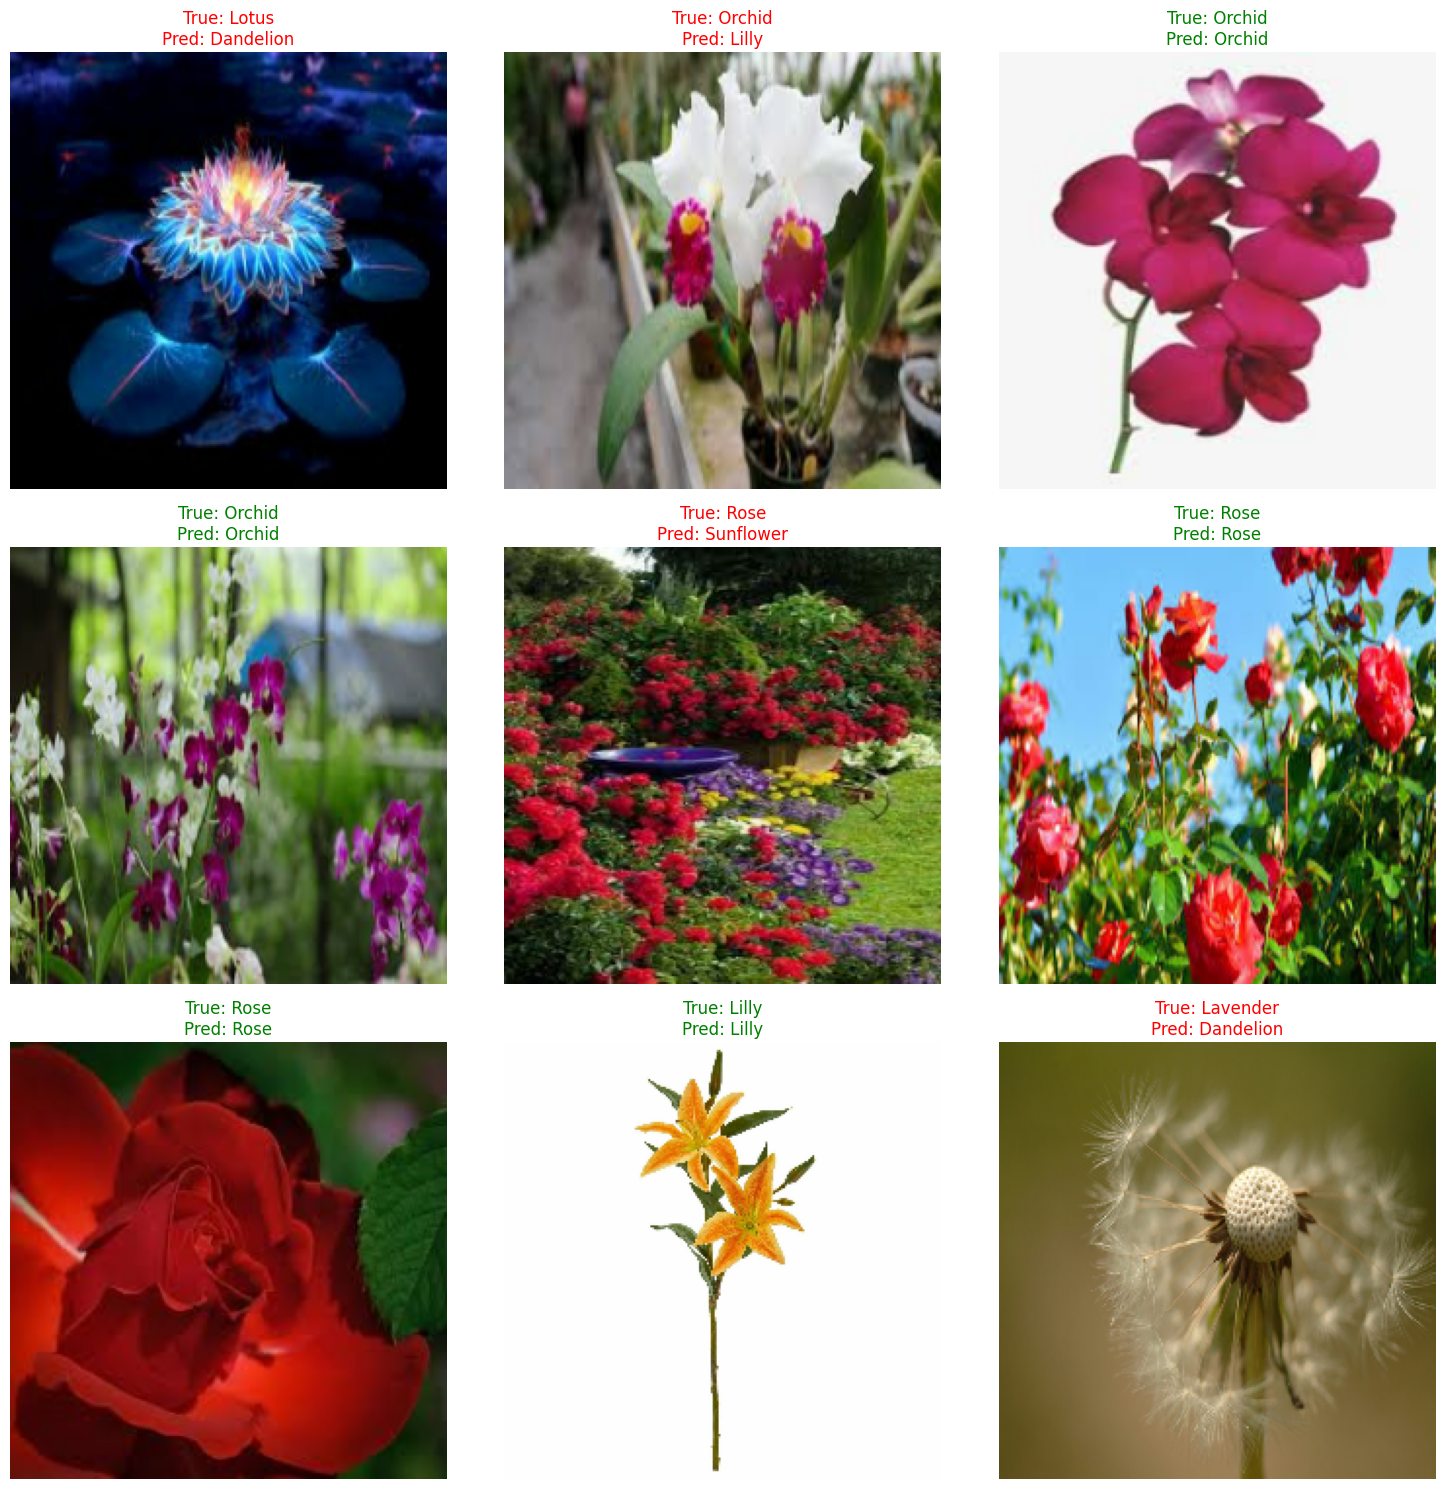

Batch accuracy: 0.69
Visualized sample predictions with true and predicted labels.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of validation images and labels
for images, labels in val_ds.take(1):
    break

# Make predictions using the new model
predictions = new_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

# Display predictions
plt.figure(figsize=(15, 15))
for i in range(min(9, len(images))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    true_label = class_names[labels[i].numpy()]
    predicted_label = class_names[predicted_labels[i]]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Calculate and print overall accuracy for this batch (optional, for context)
correct_predictions = np.sum(labels.numpy() == predicted_labels)
batch_accuracy = correct_predictions / len(labels)
print(f"Batch accuracy: {batch_accuracy:.2f}")
print("Visualized sample predictions with true and predicted labels.")